In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

(112, 92)


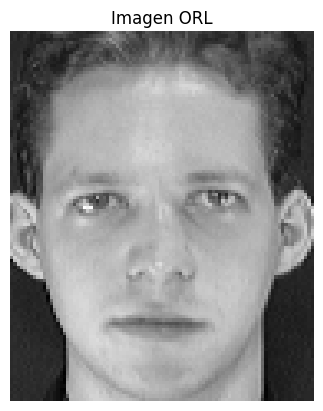

In [4]:
# Visualización de imagén del dataset
ruta = "dataset/Training/s1/1.pgm"

imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

print(imagen.shape)

plt.imshow(imagen, cmap='gray')
plt.title("Imagen ORL")
plt.axis('off')
plt.show()

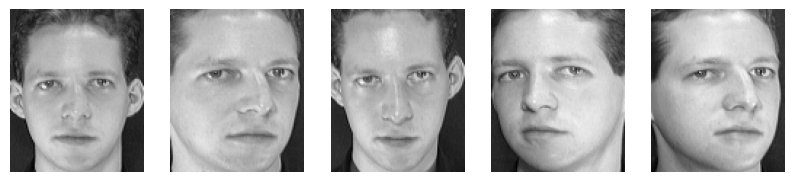

In [5]:
# Visualización de imágenes de un sujeto del dataset
persona = "dataset/Training/s1"

imagenes = os.listdir(persona)

plt.figure(figsize=(10,5))

for i, archivo in enumerate(imagenes[:5]):
    
    ruta = os.path.join(persona, archivo)
    
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.show()

In [6]:
ruta_dataset = "dataset/Training"

personas = os.listdir(ruta_dataset)

print("Cantidad de personas:", len(personas))

Cantidad de personas: 40


In [7]:
datos = []

for persona in personas:
    
    carpeta = os.path.join(ruta_dataset, persona)
    
    cantidad = len(os.listdir(carpeta))
    
    datos.append({
        "persona": persona,
        "imagenes": cantidad
    })

df = pd.DataFrame(datos)

df.head()

,persona,imagenes
0,s1,9
1,s10,9
2,s11,9
3,s12,9
4,s13,9


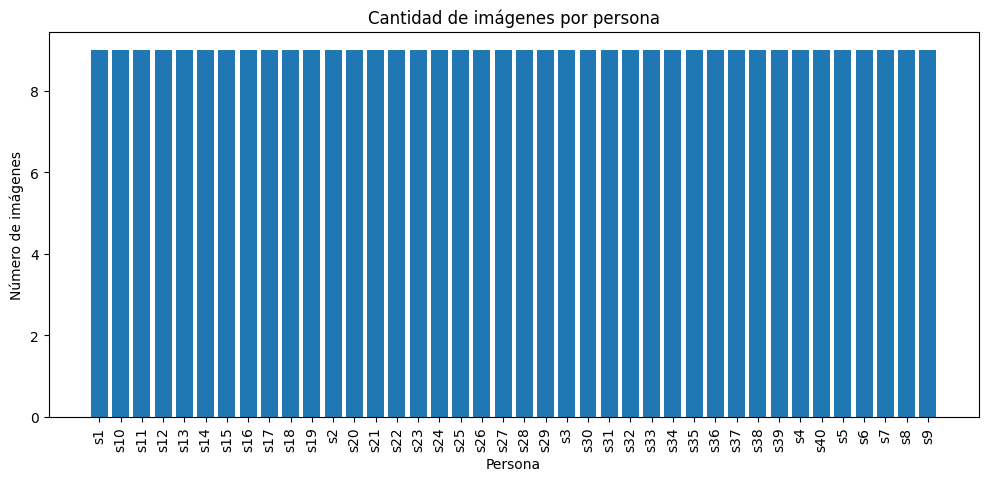

In [8]:
plt.figure(figsize=(12,5))

plt.bar(df["persona"], df["imagenes"])

plt.title("Cantidad de imágenes por persona")

plt.xlabel("Persona")

plt.ylabel("Número de imágenes")

plt.xticks(rotation=90)

plt.show()

In [9]:
persona = "s1"

ruta_persona = os.path.join(ruta_dataset, persona)

imagenes = os.listdir(ruta_persona)

ruta_imagen = os.path.join(ruta_persona, imagenes[0])

img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)

print("Dimensiones:", img.shape)

Dimensiones: (112, 92)


In [10]:
imagenes_invalidas = []

for persona in personas:
    
    carpeta = os.path.join(ruta_dataset, persona)
    
    for archivo in os.listdir(carpeta):
        
        ruta = os.path.join(carpeta, archivo)
        
        img = cv2.imread(ruta)
        
        if img is None:
            imagenes_invalidas.append(ruta)

print("Imágenes corruptas:", len(imagenes_invalidas))

Imágenes corruptas: 0


In [ ]:
def degradar_imagen(imagen, escala=4, agregar_ruido=True, sigma_ruido=5):
    h, w = imagen.shape
    blur = cv2.GaussianBlur(imagen, (5, 5), sigmaX=1.0)

    lr_small = cv2.resize(blur, (w // escala, h // escala),
                          interpolation=cv2.INTER_LINEAR)

    lr_upscaled = cv2.resize(lr_small, (w, h),
                             interpolation=cv2.INTER_LINEAR)

    if agregar_ruido:
        ruido = np.random.normal(0, sigma_ruido, lr_upscaled.shape).astype(np.float32)
        lr_upscaled = np.clip(lr_upscaled.astype(np.float32) + ruido, 0, 255).astype(np.uint8)

    return lr_upscaled

In [12]:
def aplicar_clahe(imagen_gray, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(imagen_gray)

In [13]:
def pipeline_preprocesamiento(imagen_hr, escala=4, clip_limit=2.0, tile_grid_size=(8, 8)):
    lr = degradar_imagen(imagen_hr, escala=escala)
    lr_clahe = aplicar_clahe(lr, clip_limit, tile_grid_size)

    # Normalización final para el modelo (rango [0,1] o [-1,1])
    lr_normalizada = lr_clahe.astype(np.float32) / 255.0  

    return {
        "hr":           imagen_hr,
        "lr":           lr,
        "lr_clahe":     lr_clahe,
        "lr_norm":      lr_normalizada
    }

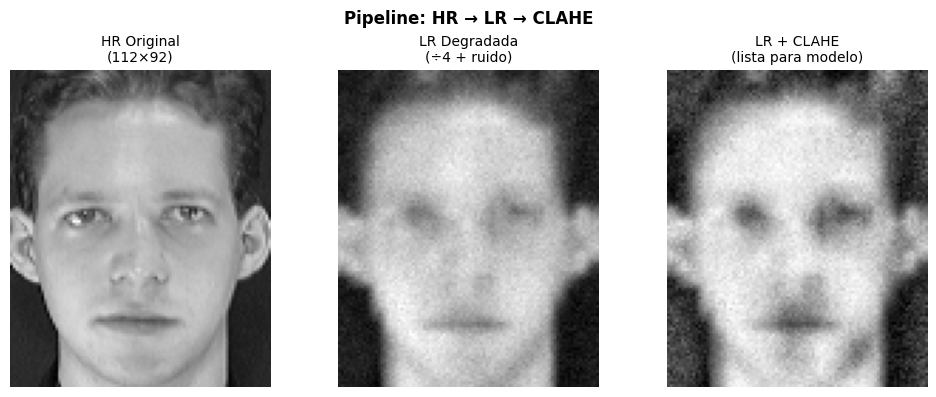

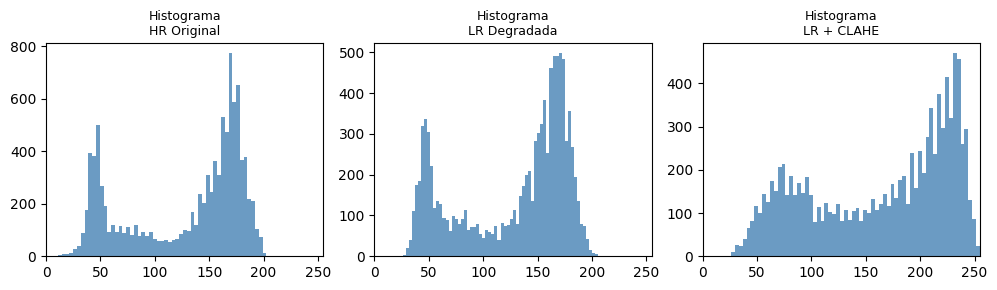

In [14]:
ruta = "dataset/Training/s1/1.pgm"
imagen_hr = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

etapas = pipeline_preprocesamiento(imagen_hr, escala=4)

titulos = ["HR Original\n(112×92)", "LR Degradada\n(÷4 + ruido)", "LR + CLAHE\n(lista para modelo)"]
imgs    = [etapas["hr"], etapas["lr"], etapas["lr_clahe"]]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, img, titulo in zip(axes, imgs, titulos):
    ax.imshow(img, cmap='gray')
    ax.set_title(titulo, fontsize=10)
    ax.axis('off')

plt.suptitle("Pipeline: HR → LR → CLAHE", fontweight='bold')
plt.tight_layout()
plt.show()

# Histogramas para verificar mejora de contraste
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, img, titulo in zip(axes, imgs, titulos):
    ax.hist(img.ravel(), bins=64, color='steelblue', alpha=0.8)
    ax.set_title(f"Histograma\n{titulo.split(chr(10))[0]}", fontsize=9)
    ax.set_xlim([0, 255])

plt.tight_layout()
plt.show()

In [15]:
def procesar_dataset_completo(ruta_entrada, ruta_salida,
                               escala=4, clip_limit=2.0, tile_grid_size=(8, 8)):
    os.makedirs(ruta_salida, exist_ok=True)
    conteo = 0

    for sujeto in sorted(os.listdir(ruta_entrada)):
        carpeta_entrada = os.path.join(ruta_entrada, sujeto)
        if not os.path.isdir(carpeta_entrada):
            continue

        carpeta_salida = os.path.join(ruta_salida, sujeto)
        os.makedirs(carpeta_salida, exist_ok=True)

        for archivo in sorted(os.listdir(carpeta_entrada)):
            ruta_img = os.path.join(carpeta_entrada, archivo)
            img_hr = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
            if img_hr is None:
                continue

            resultado = pipeline_preprocesamiento(img_hr, escala, clip_limit, tile_grid_size)

            # Guardar imagen lista para MobileFaceNet
            nombre = os.path.splitext(archivo)[0] + ".png"
            cv2.imwrite(os.path.join(carpeta_salida, nombre), resultado["lr_clahe"])
            conteo += 1

    print(f" {conteo} imágenes procesadas → {ruta_salida}")


#procesar_dataset_completo(
#    ruta_entrada="dataset/Training",
#    ruta_salida="dataset/Training_LR_CLAHE",
#    escala=4,
#    clip_limit=2.0,
#    tile_grid_size=(8, 8)
#)
procesar_dataset_completo(
    ruta_entrada   = "dataset/Testing",
    ruta_salida    = "dataset/Testing_LR_CLAHE_escala4",
    escala         = 4,
    clip_limit     = 2.0,
    tile_grid_size = (8, 8)
)

 40 imágenes procesadas → dataset/Testing_LR_CLAHE_escala4


Text(0.5, 1.0, 'Imagen ORL')

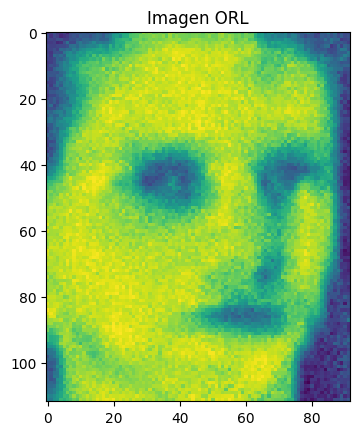

In [11]:
# Visualización de imagén del dataset
ruta = "dataset/Training_LR_CLAHE/s1/2.png"

imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen)
plt.title("Imagen ORL")


In [16]:
def pipeline_preprocesamiento(imagen_hr, escala=2, clip_limit=2.0, tile_grid_size=(8, 8)):
    h, w = imagen_hr.shape

    blur      = cv2.GaussianBlur(imagen_hr, (3, 3), sigmaX=0.5)
    lr_small  = cv2.resize(blur, (w // escala, h // escala), interpolation=cv2.INTER_LINEAR)

    ruido    = np.random.normal(0, 5, lr_small.shape).astype(np.float32)
    lr_small = np.clip(lr_small.astype(np.float32) + ruido, 0, 255).astype(np.uint8)

    lr = cv2.resize(lr_small, (w, h), interpolation=cv2.INTER_CUBIC)

    clahe    = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    lr_clahe = clahe.apply(lr)

    return {"hr": imagen_hr, "lr": lr, "lr_clahe": lr_clahe}

In [17]:
def procesar_dataset_completo(ruta_entrada, ruta_salida,
                               escala=2, clip_limit=2.0, tile_grid_size=(8, 8)):
    os.makedirs(ruta_salida, exist_ok=True)
    conteo = 0

    for sujeto in sorted(os.listdir(ruta_entrada)):
        carpeta_entrada = os.path.join(ruta_entrada, sujeto)
        if not os.path.isdir(carpeta_entrada):
            continue

        carpeta_salida = os.path.join(ruta_salida, sujeto)
        os.makedirs(carpeta_salida, exist_ok=True)

        for archivo in sorted(os.listdir(carpeta_entrada)):
            ruta_img = os.path.join(carpeta_entrada, archivo)
            img_hr   = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
            if img_hr is None:
                continue

            resultado = pipeline_preprocesamiento(img_hr, escala, clip_limit, tile_grid_size)

            nombre = os.path.splitext(archivo)[0] + ".png"
            cv2.imwrite(os.path.join(carpeta_salida, nombre), resultado["lr_clahe"])
            conteo += 1

    print(f" {conteo} imágenes procesadas → {ruta_salida}")


#procesar_dataset_completo(
#    ruta_entrada = "dataset/Training",
#    ruta_salida  = "dataset/Training_LR_CLAHE_escala2",  # ← nueva carpeta
#    escala       = 2,
#    clip_limit   = 2.0,
#    tile_grid_size = (8, 8)
#)
procesar_dataset_completo(
    ruta_entrada   = "dataset/Testing",
    ruta_salida    = "dataset/Testing_LR_CLAHE_escala2",
    escala         = 2,
    clip_limit     = 2.0,
    tile_grid_size = (8, 8)
)


 40 imágenes procesadas → dataset/Testing_LR_CLAHE_escala2
